# Validation Post-Processing Evaluator

This notebook is for validation-split tuning only. Do not use the reserved local holdout split for repeated post-processing experiments.

The script `evaluate_validation_postprocess.py` is the source of truth. These cells import its helpers so the notebook stays thin and easy to compare against command-line runs.

In [2]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "train_baseline.py").exists() and (PROJECT_ROOT.parent / "train_baseline.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/einar/projects/INF367A-26V-Recod.ai-LUC-Forgery-Kaggle


## Configuration

`ALLOW_TORCH_HUB` must be changed to `True` before the model is reconstructed. That is intentional because model construction uses official DINO through `torch.hub` and may initialize or download cached DINO assets.

In [ ]:
CHECKPOINT_PATH = Path("runs/checkpoints/best_by_kaggle_score.pt")
DEVICE = "auto"
ALLOW_TORCH_HUB = True

# Set to True only for final one-shot holdout evaluation — do not use for tuning.
RUN_HOLDOUT = False

# Keep this small while exploring. Set any list to None to use the checkpoint/config value.
PRED_THRESHOLDS = [0.40, 0.45, 0.50]
MIN_COMPONENT_AREAS = None
CONFIDENT_THRESHOLDS = None
SMOOTH_OPTIONS = None
OPENING_OPTIONS = None
CLOSING_OPTIONS = None
FILL_HOLES_OPTIONS = None
KEEP_CONFIDENT_SEEDED_OPTIONS = [False, True]
MAX_SETTINGS = 12
SCORE_TOLERANCE = 1e-2
ALLOW_SCORE_MISMATCH = False

# Max-inspired broader sweep. Current repo post-processing has Max's main knobs
# (threshold, confident seeds, smoothing, opening/closing, fill holes, min area),
# while exact Max ordering is still a possible follow-up experiment.
BROAD_SWEEP_PRESET = True
if BROAD_SWEEP_PRESET:
    PRED_THRESHOLDS = [0.35, 0.40, 0.45, 0.50, 0.55]
    MIN_COMPONENT_AREAS = [25, 50, 100, 200, 400]
    CONFIDENT_THRESHOLDS = [0.75, 0.85, 0.90, 0.95, None]
    SMOOTH_OPTIONS = [False]
    OPENING_OPTIONS = [True]
    CLOSING_OPTIONS = [False]
    FILL_HOLES_OPTIONS = [True, False]
    KEEP_CONFIDENT_SEEDED_OPTIONS = [True]
    MAX_SETTINGS = 250

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT_PATH}")
print(f"Checkpoint found: {CHECKPOINT_PATH}")

CHECKPOINT_PATH

In [4]:
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image

from configs.baseline_config import set_seed
from dataset_utils import list_labeled_samples
from datasets.splits import make_grouped_stratified_splits
from engine.checkpointing import load_checkpoint
from engine.validation_inference import (
    _post_process_probability,
    collect_validation_predictions,
    score_validation_predictions,
)
from engine.validation_records import (
    connected_components_to_masks,
    load_resized_instance_masks,
    score_instances,
)
from evaluate_validation_postprocess import (
    _build_sliding_window_fn,
    _build_val_loader,
    _resolve_device,
    config_from_checkpoint,
    iter_postprocess_settings,
    validate_model_loading_allowed,
    validate_reproduced_validation_score,
)
from models.dino_segmenter import DinoSegmenter
from util.pixelmapUtil import PixelMapUtil

## Rebuild Validation Split

This uses the checkpoint config to rebuild the same grouped train/validation/local-test split used during training. Only `splits["val"]` is loaded below.

In [5]:
device = _resolve_device(DEVICE)

# Trusted local checkpoint only. Loading is kept on CPU until the model is explicitly built.
checkpoint = load_checkpoint(CHECKPOINT_PATH, map_location="cpu", trusted=True)
config = config_from_checkpoint(checkpoint)
set_seed(config.seed)

all_samples = list_labeled_samples(Path(config.data_root))
splits = make_grouped_stratified_splits(
    all_samples,
    seed=config.seed,
    train_ratio=config.train_ratio,
    val_ratio=config.val_ratio,
    test_ratio=config.test_ratio,
)
val_samples = splits["val"]
if config.val_subset is not None:
    val_samples = val_samples[: config.val_subset]

print(f"Device: {device}")
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Checkpoint epoch: {checkpoint.get('epoch', 'unknown')}")
print(f"Stored validation kaggle_score: {checkpoint.get('kaggle_score', 'unknown')}")
print(f"Validation samples: {len(val_samples)}")

Device: cuda
Checkpoint: runs/checkpoints/best_by_kaggle_score.pt
Checkpoint epoch: 4
Stored validation kaggle_score: 0.4815205174162818
Validation samples: 514


## Cache Validation Probabilities

This is the only expensive cell. It reconstructs the model, loads the checkpoint weights, runs validation inference once, and keeps probability maps in memory for repeated post-processing sweeps.

In [6]:
validate_model_loading_allowed(ALLOW_TORCH_HUB)
print("Model reconstruction explicitly allowed for this local notebook run.")

val_loader = _build_val_loader(config, val_samples, device)
pixel_util = PixelMapUtil()
model = DinoSegmenter.from_official(
    model_name=config.dino_model_name,
    embed_dim=config.dino_embed_dim,
    freeze_encoder=config.freeze_dino_encoder,
).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

predictions = collect_validation_predictions(
    model=model,
    val_loader=val_loader,
    val_samples=val_samples,
    device=device,
    inference_mode=config.validation_inference_mode,
    sliding_window_fn=_build_sliding_window_fn(config),
    probability_dtype=config.validation_probability_dtype,
    collect_masks=config.compute_pixel_f1,
    transfer_mode=config.validation_transfer_mode,
)

baseline_result = score_validation_predictions(
    predictions=predictions,
    pixel_util=pixel_util,
    pred_threshold=config.pred_threshold,
    harden_temperature=config.harden_temperature,
    hard_clip_low=config.hard_clip_low,
    hard_clip_high=config.hard_clip_high,
    min_component_area=config.min_component_area,
    compute_pixel_f1=config.compute_pixel_f1,
    verify_score_equivalence=config.verify_score_equivalence,
    confident_threshold=config.post_process_confident_threshold,
    smooth_probabilities=config.post_process_smooth_probabilities,
    fill_holes=config.post_process_fill_holes,
    apply_opening=config.post_process_apply_opening,
    apply_closing=config.post_process_apply_closing,
    keep_confident_seeded_components=config.post_process_keep_confident_seeded_components,
)
stored_validation_score = checkpoint.get("kaggle_score")
validate_reproduced_validation_score(
    stored_score=stored_validation_score,
    reproduced_score=baseline_result["kaggle_score"],
    tolerance=SCORE_TOLERANCE,
    allow_mismatch=ALLOW_SCORE_MISMATCH,
)
if stored_validation_score is not None:
    print(
        "Stored/reproduced validation delta: "
        f"{abs(float(stored_validation_score) - baseline_result['kaggle_score']):.6f}"
    )
baseline_result

Model reconstruction explicitly allowed for this local notebook run.


Using cache found in /home/einar/.cache/torch/hub/facebookresearch_dinov2_main


Stored/reproduced validation delta: 0.000988


{'kaggle_score': 0.48053225364657476,
 'pixel_f1': None,
 'num_samples': 514,
 'num_forged': 276,
 'num_authentic': 238,
 'postprocess_seconds': 3.711213675998806,
 'scoring_seconds': 0.08046513400040567}

## Sweep Post-Processing Settings

The model is not run again here. Each row reuses the cached validation probabilities.

In [7]:
sweep_args = SimpleNamespace(
    pred_thresholds=PRED_THRESHOLDS or [config.pred_threshold],
    min_component_areas=MIN_COMPONENT_AREAS or [config.min_component_area],
    confident_thresholds=CONFIDENT_THRESHOLDS or [config.post_process_confident_threshold],
    smooth_options=SMOOTH_OPTIONS or [config.post_process_smooth_probabilities],
    opening_options=OPENING_OPTIONS or [config.post_process_apply_opening],
    closing_options=CLOSING_OPTIONS or [config.post_process_apply_closing],
    fill_holes_options=FILL_HOLES_OPTIONS or [config.post_process_fill_holes],
    keep_confident_seeded_options=KEEP_CONFIDENT_SEEDED_OPTIONS or [
        config.post_process_keep_confident_seeded_components
    ],
    max_settings=MAX_SETTINGS,
)

rows = []
for rank, setting in enumerate(iter_postprocess_settings(config, sweep_args), start=1):
    result = score_validation_predictions(
        predictions=predictions,
        pixel_util=pixel_util,
        pred_threshold=setting["pred_threshold"],
        harden_temperature=setting["harden_temperature"],
        hard_clip_low=setting["hard_clip_low"],
        hard_clip_high=setting["hard_clip_high"],
        min_component_area=setting["min_component_area"],
        compute_pixel_f1=setting["compute_pixel_f1"],
        verify_score_equivalence=setting["verify_score_equivalence"],
        confident_threshold=setting["confident_threshold"],
        smooth_probabilities=setting["smooth_probabilities"],
        fill_holes=setting["fill_holes"],
        apply_opening=setting["apply_opening"],
        apply_closing=setting["apply_closing"],
        keep_confident_seeded_components=setting["keep_confident_seeded_components"],
    )
    rows.append({"rank": rank, **setting, **result})

sweep_df = pd.DataFrame(rows).sort_values("kaggle_score", ascending=False).reset_index(drop=True)
best_setting = sweep_df.iloc[0].to_dict() if len(sweep_df) else None

baseline_setting = {
    "pred_threshold": config.pred_threshold,
    "harden_temperature": config.harden_temperature,
    "hard_clip_low": config.hard_clip_low,
    "hard_clip_high": config.hard_clip_high,
    "min_component_area": config.min_component_area,
    "confident_threshold": config.post_process_confident_threshold,
    "smooth_probabilities": config.post_process_smooth_probabilities,
    "fill_holes": config.post_process_fill_holes,
    "apply_opening": config.post_process_apply_opening,
    "apply_closing": config.post_process_apply_closing,
    "keep_confident_seeded_components": config.post_process_keep_confident_seeded_components,
}
tuned_setting = best_setting or baseline_setting
sweep_df

,rank,pred_threshold,min_component_area,confident_threshold,smooth_probabilities,apply_opening,apply_closing,fill_holes,keep_confident_seeded_components,harden_temperature,...,hard_clip_high,compute_pixel_f1,verify_score_equivalence,kaggle_score,pixel_f1,num_samples,num_forged,num_authentic,postprocess_seconds,scoring_seconds
0,3,0.35,25,0.85,False,True,False,True,True,0.7,...,0.9,False,False,0.509530,None,514,276,238,3.733134,0.038250
1,13,0.35,50,0.85,False,True,False,True,True,0.7,...,0.9,False,False,0.509530,None,514,276,238,3.676166,0.037912
2,23,0.35,100,0.85,False,True,False,True,True,0.7,...,0.9,False,False,0.509530,None,514,276,238,3.774420,0.037718
3,33,0.35,200,0.85,False,True,False,True,True,0.7,...,0.9,False,False,0.509530,None,514,276,238,3.705088,0.042089
4,43,0.35,400,0.85,False,True,False,True,True,0.7,...,0.9,False,False,0.509530,None,514,276,238,3.672475,0.038230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,211,0.55,50,0.75,False,True,False,True,True,0.7,...,0.9,False,False,0.496551,None,514,276,238,3.651276,0.054270
246,232,0.55,200,0.75,False,True,False,False,True,0.7,...,0.9,False,False,0.496398,None,514,276,238,2.091324,0.050234
247,202,0.55,25,0.75,False,True,False,False,True,0.7,...,0.9,False,False,0.496357,None,514,276,238,2.062331,0.052332
248,212,0.55,50,0.75,False,True,False,False,True,0.7,...,0.9,False,False,0.496357,None,514,276,238,2.063111,0.049408


In [8]:
from datetime import datetime

SWEEP_OUTPUT_DIR = Path("runs/eval_sweeps")
SWEEP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
checkpoint_stem = CHECKPOINT_PATH.stem
sweep_path = SWEEP_OUTPUT_DIR / f"{checkpoint_stem}_validation_postprocess_sweep_{timestamp}.csv"

sweep_df.to_csv(sweep_path, index=False)
print(f"Saved sweep results to: {sweep_path}")

Saved sweep results to: runs/eval_sweeps/best_by_kaggle_score_validation_postprocess_sweep_20260420_141555.csv


## Post-Processing Diagnostics

These tables explain whether a setting improves by reducing authentic false positives, reducing forged misses, changing component counts, or changing predicted area. This is validation-split analysis only.

In [9]:
def mask_from_setting(prediction, setting):
    return _post_process_probability(
        probability=prediction.probability,
        pixel_util=pixel_util,
        pred_threshold=setting["pred_threshold"],
        harden_temperature=setting["harden_temperature"],
        hard_clip_low=setting["hard_clip_low"],
        hard_clip_high=setting["hard_clip_high"],
        min_component_area=setting["min_component_area"],
        confident_threshold=setting["confident_threshold"],
        smooth_probabilities=setting["smooth_probabilities"],
        fill_holes=setting["fill_holes"],
        apply_opening=setting["apply_opening"],
        apply_closing=setting["apply_closing"],
        keep_confident_seeded_components=setting["keep_confident_seeded_components"],
    )


def gt_instances_for_prediction(prediction, shape):
    if prediction.sample.label == "authentic":
        return []
    return load_resized_instance_masks(prediction.sample, shape)


def compute_setting_diagnostics(setting, setting_name):
    rows = []
    for prediction in predictions:
        pred_mask = mask_from_setting(prediction, setting)
        pred_instances = connected_components_to_masks(pred_mask)
        gt_instances = gt_instances_for_prediction(prediction, pred_mask.shape)
        pred_area = int(pred_mask.sum())
        probability = prediction.probability.astype(np.float32)
        rows.append(
            {
                "setting_name": setting_name,
                "sample_id": prediction.sample.sample_id,
                "case_id": prediction.sample.case_id,
                "label": prediction.sample.label,
                "sample_score": score_instances(pred_instances, gt_instances),
                "pred_components": len(pred_instances),
                "gt_components": len(gt_instances),
                "pred_area": pred_area,
                "gt_area": int(sum(mask.sum() for mask in gt_instances)),
                "max_probability": float(probability.max()),
                "mean_probability": float(probability.mean()),
                "mean_pred_probability": float(probability[pred_mask.astype(bool)].mean()) if pred_area else 0.0,
            }
        )
    return pd.DataFrame(rows)


diagnostic_df = pd.concat(
    [
        compute_setting_diagnostics(baseline_setting, "baseline"),
        compute_setting_diagnostics(tuned_setting, "best_sweep"),
    ],
    ignore_index=True,
)

diagnostic_overview = []
for setting_name, group in diagnostic_df.groupby("setting_name"):
    authentic = group[group["label"] == "authentic"]
    forged = group[group["label"] == "forged"]
    diagnostic_overview.append(
        {
            "setting_name": setting_name,
            "kaggle_score": group["sample_score"].mean(),
            "authentic_false_positive_rate": (authentic["pred_components"] > 0).mean(),
            "forged_empty_prediction_rate": (forged["pred_components"] == 0).mean(),
            "authentic_mean_score": authentic["sample_score"].mean(),
            "forged_mean_score": forged["sample_score"].mean(),
            "mean_pred_components": group["pred_components"].mean(),
            "median_pred_area": group["pred_area"].median(),
        }
    )
diagnostic_overview = pd.DataFrame(diagnostic_overview).sort_values("kaggle_score", ascending=False)

label_diagnostics = (
    diagnostic_df.groupby(["setting_name", "label"])
    .agg(
        sample_count=("sample_id", "count"),
        mean_score=("sample_score", "mean"),
        mean_pred_components=("pred_components", "mean"),
        mean_pred_area=("pred_area", "mean"),
        median_max_probability=("max_probability", "median"),
    )
    .reset_index()
)

authentic_false_positives = diagnostic_df[
    (diagnostic_df["label"] == "authentic") & (diagnostic_df["pred_components"] > 0)
].sort_values(["setting_name", "pred_area"], ascending=[True, False])

forged_low_scores = diagnostic_df[
    (diagnostic_df["label"] == "forged") & (diagnostic_df["sample_score"] < 0.5)
].sort_values(["setting_name", "sample_score", "pred_area"])

display(diagnostic_overview)
display(label_diagnostics)
display(authentic_false_positives.head(20))
display(forged_low_scores.head(20))

,setting_name,kaggle_score,authentic_false_positive_rate,forged_empty_prediction_rate,authentic_mean_score,forged_mean_score,mean_pred_components,median_pred_area
1,best_sweep,0.509530,0.033613,0.724638,0.966387,0.115574,0.237354,0.0
0,baseline,0.480532,0.071429,0.623188,0.928571,0.094180,0.546693,0.0


,setting_name,label,sample_count,mean_score,mean_pred_components,mean_pred_area,median_max_probability
0,baseline,authentic,238,0.928571,0.121849,412.029412,0.138367
1,baseline,forged,276,0.094180,0.913043,3748.927536,0.332397
2,best_sweep,authentic,238,0.966387,0.037815,392.331933,0.138367
3,best_sweep,forged,276,0.115574,0.409420,4239.525362,0.332397


,setting_name,sample_id,case_id,label,sample_score,pred_components,gt_components,pred_area,gt_area,max_probability,mean_probability,mean_pred_probability
503,baseline,authentic:7759,7759,authentic,0.0,1,0,34716,0,0.937012,0.185214,0.710505
143,baseline,authentic:24980,24980,authentic,0.0,4,0,19794,0,0.968750,0.120626,0.791544
110,baseline,authentic:21706,21706,authentic,0.0,3,0,12480,0,0.860352,0.106059,0.656247
343,baseline,authentic:48880,48880,authentic,0.0,1,0,7675,0,0.824219,0.062154,0.626608
339,baseline,authentic:48293,48293,authentic,0.0,4,0,5813,0,0.731934,0.084975,0.582421
0,baseline,authentic:10030,10030,authentic,0.0,2,0,3205,0,0.851074,0.035110,0.614387
369,baseline,authentic:5175,5175,authentic,0.0,1,0,3023,0,0.707031,0.056599,0.567574
127,baseline,authentic:230,230,authentic,0.0,1,0,2928,0,0.858398,0.038595,0.655526
118,baseline,authentic:22821,22821,authentic,0.0,2,0,1632,0,0.697754,0.031655,0.585125
252,baseline,authentic:37980,37980,authentic,0.0,1,0,1630,0,0.592773,0.066299,0.546686


,setting_name,sample_id,case_id,label,sample_score,pred_components,gt_components,pred_area,gt_area,max_probability,mean_probability,mean_pred_probability
11,baseline,forged:11010,11010,forged,0.0,0,2,0,479,0.061310,0.001801,0.0
17,baseline,forged:11747,11747,forged,0.0,0,2,0,813,0.136475,0.004658,0.0
19,baseline,forged:11904,11904,forged,0.0,0,1,0,3877,0.399658,0.005498,0.0
21,baseline,forged:11954,11954,forged,0.0,0,2,0,1074,0.057312,0.007831,0.0
23,baseline,forged:12046,12046,forged,0.0,0,1,0,552,0.143311,0.003583,0.0
25,baseline,forged:13108,13108,forged,0.0,0,1,0,1607,0.516113,0.006541,0.0
29,baseline,forged:13254,13254,forged,0.0,0,1,0,2068,0.033112,0.002562,0.0
33,baseline,forged:13986,13986,forged,0.0,0,2,0,113,0.106445,0.003690,0.0
34,baseline,forged:14111,14111,forged,0.0,0,3,0,626,0.328613,0.005329,0.0
35,baseline,forged:14153,14153,forged,0.0,0,1,0,357,0.121826,0.001331,0.0


In [10]:
diagnostics_path = SWEEP_OUTPUT_DIR / f"{checkpoint_stem}_validation_postprocess_diagnostics_{timestamp}.csv"
diagnostic_df.to_csv(diagnostics_path, index=False)
print(f"Saved per-sample diagnostics to: {diagnostics_path}")
overview_path = SWEEP_OUTPUT_DIR / f"{checkpoint_stem}_validation_postprocess_overview_{timestamp}.csv"
diagnostic_overview.to_csv(overview_path, index=False)
print(f"Saved diagnostics overview to: {overview_path}")


Saved per-sample diagnostics to: runs/eval_sweeps/best_by_kaggle_score_validation_postprocess_diagnostics_20260420_141555.csv
Saved diagnostics overview to: runs/eval_sweeps/best_by_kaggle_score_validation_postprocess_overview_20260420_141555.csv


## Inspect Examples

These examples compare the baseline mask with the best setting from the sweep above.

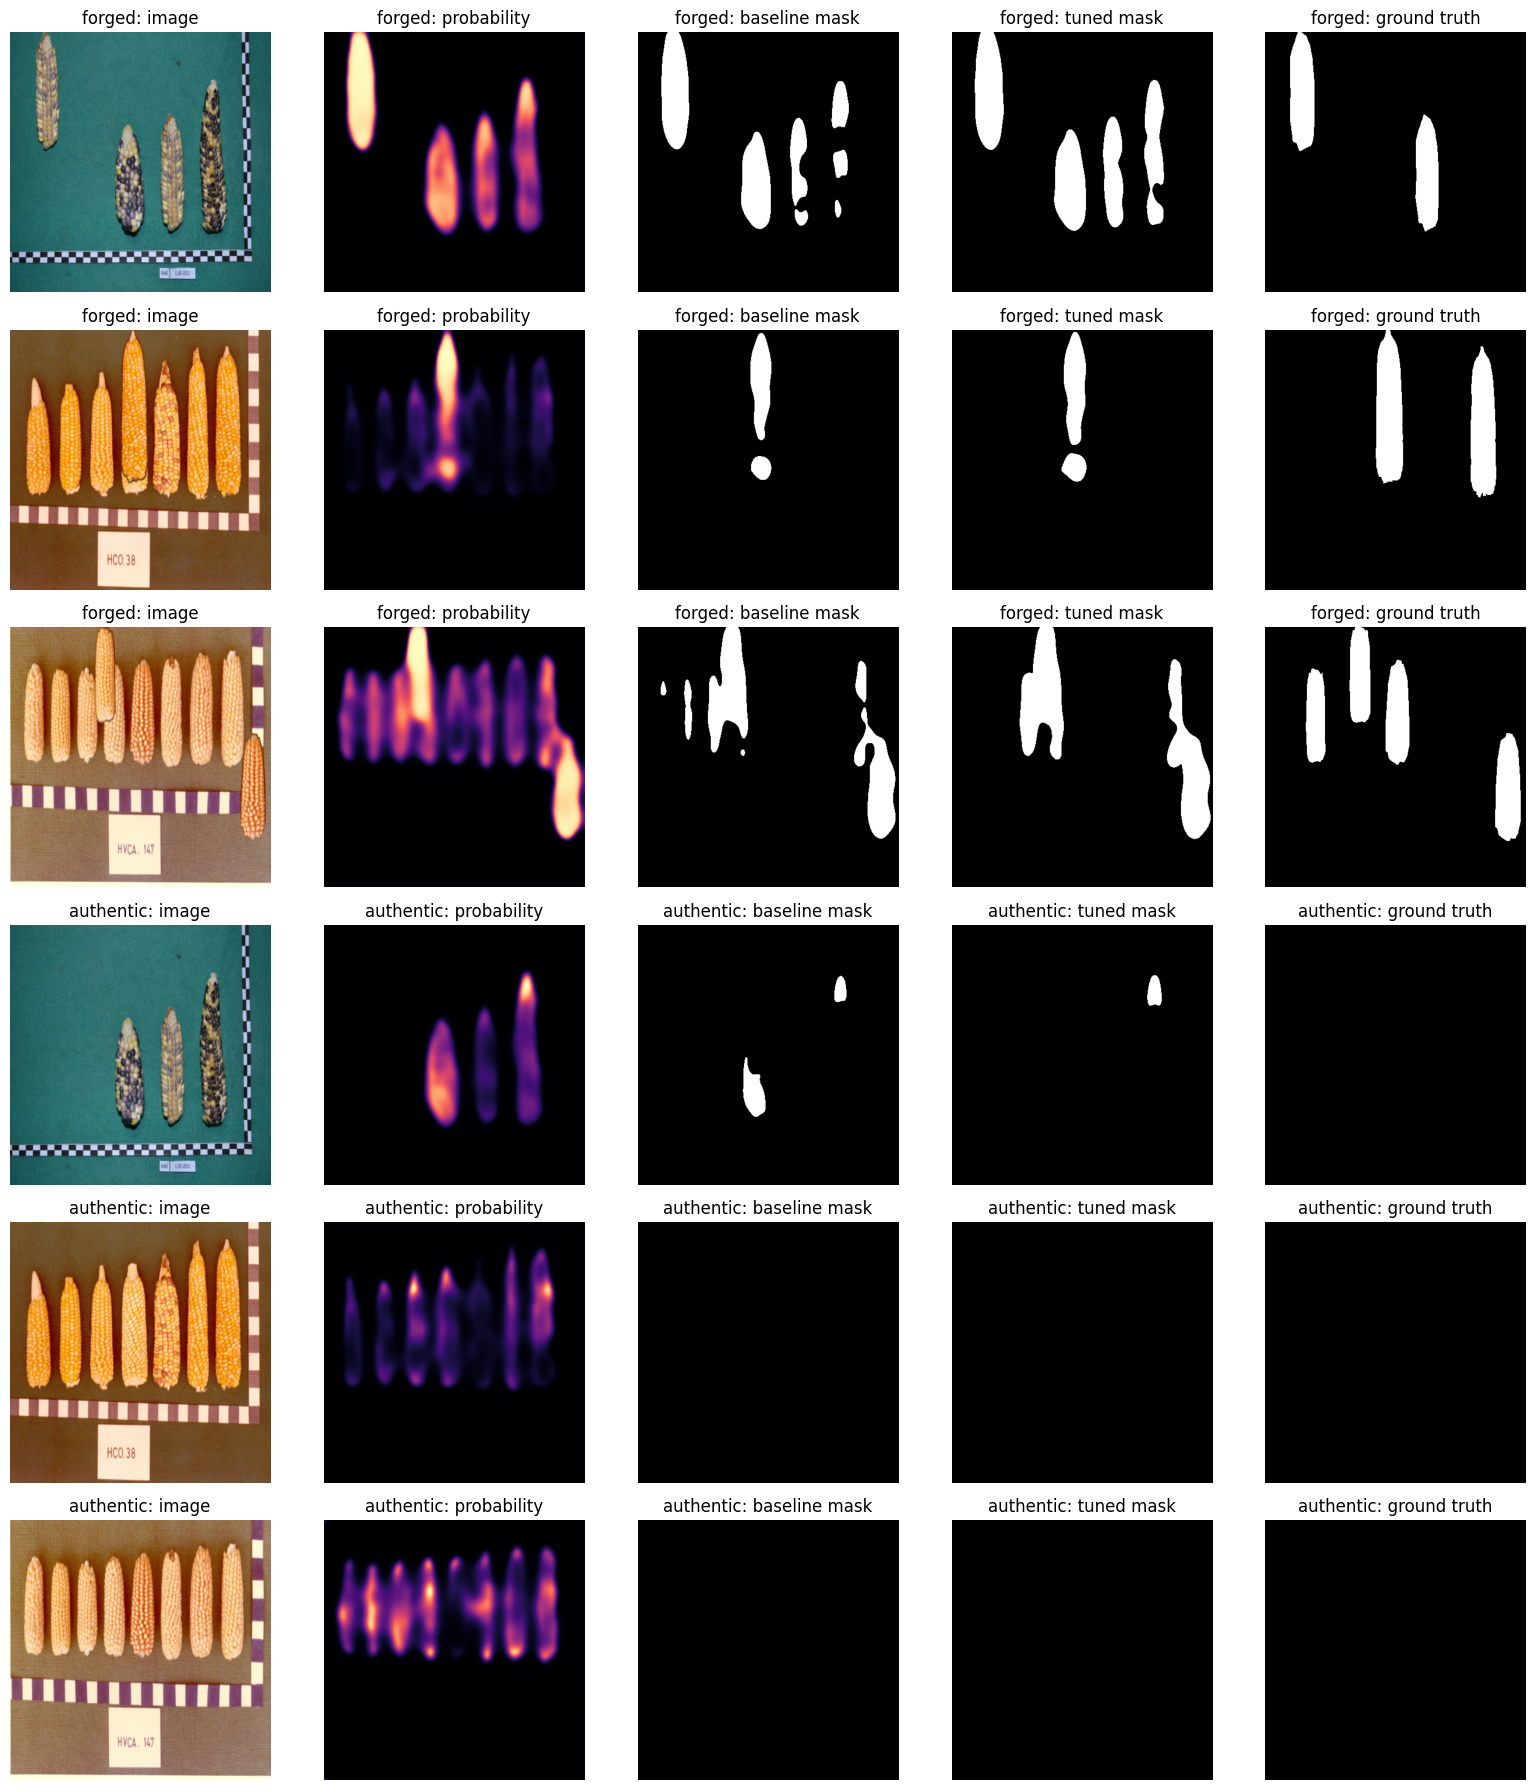

In [12]:
def gt_union_for_prediction(prediction):
    shape = prediction.probability.shape
    if prediction.sample.label == "authentic":
        return np.zeros(shape, dtype=np.uint8)
    instances = load_resized_instance_masks(prediction.sample, shape)
    union = np.zeros(shape, dtype=np.uint8)
    for mask in instances:
        union = np.maximum(union, mask.astype(np.uint8))
    return union


def mask_from_setting(prediction, setting):
    return _post_process_probability(
        probability=prediction.probability,
        pixel_util=pixel_util,
        pred_threshold=setting["pred_threshold"],
        harden_temperature=setting["harden_temperature"],
        hard_clip_low=setting["hard_clip_low"],
        hard_clip_high=setting["hard_clip_high"],
        min_component_area=setting["min_component_area"],
        confident_threshold=setting["confident_threshold"],
        smooth_probabilities=setting["smooth_probabilities"],
        fill_holes=setting["fill_holes"],
        apply_opening=setting["apply_opening"],
        apply_closing=setting["apply_closing"],
        keep_confident_seeded_components=setting["keep_confident_seeded_components"],
    )


baseline_setting = {
    "pred_threshold": config.pred_threshold,
    "harden_temperature": config.harden_temperature,
    "hard_clip_low": config.hard_clip_low,
    "hard_clip_high": config.hard_clip_high,
    "min_component_area": config.min_component_area,
    "confident_threshold": config.post_process_confident_threshold,
    "smooth_probabilities": config.post_process_smooth_probabilities,
    "fill_holes": config.post_process_fill_holes,
    "apply_opening": config.post_process_apply_opening,
    "apply_closing": config.post_process_apply_closing,
    "keep_confident_seeded_components": config.post_process_keep_confident_seeded_components,
}
tuned_setting = best_setting or baseline_setting

forged_examples = [prediction for prediction in predictions if prediction.sample.label == "forged"][:3]
authentic_examples = [prediction for prediction in predictions if prediction.sample.label == "authentic"][:3]
examples = forged_examples + authentic_examples

if not examples:
    print("No cached predictions available to display.")
else:
    fig, axes = plt.subplots(len(examples), 5, figsize=(16, max(3, 3 * len(examples))))
    if len(examples) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, prediction in enumerate(examples):
        probability = prediction.probability.astype(np.float32)
        image = Image.open(prediction.sample.image_path).convert("RGB").resize(
            (probability.shape[1], probability.shape[0]),
            Image.Resampling.BILINEAR,
        )
        panels = [
            (image, "image", None),
            (probability, "probability", "magma"),
            (mask_from_setting(prediction, baseline_setting), "baseline mask", "gray"),
            (mask_from_setting(prediction, tuned_setting), "tuned mask", "gray"),
            (gt_union_for_prediction(prediction), "ground truth", "gray"),
        ]
        for col_idx, (panel, title, cmap) in enumerate(panels):
            ax = axes[row_idx, col_idx]
            ax.imshow(panel, cmap=cmap)
            ax.set_title(f"{prediction.sample.label}: {title}")
            ax.axis("off")

    plt.tight_layout()

## Holdout Evaluation

One-shot evaluation on the reserved local holdout split. Only run this for final reporting — not for post-processing tuning. Controlled by `RUN_HOLDOUT` in the configuration cell above.

In [ ]:
if not RUN_HOLDOUT:
    print(
        "Holdout evaluation not run.\n"
        "Set RUN_HOLDOUT = True in the configuration cell only for final one-shot evaluation — "
        "do not use for repeated tuning."
    )
else:
    holdout_samples = splits["test"]
    print(f"Holdout samples: {len(holdout_samples)}")

    holdout_loader = _build_val_loader(config, holdout_samples, device)

    holdout_predictions = collect_validation_predictions(
        model=model,
        val_loader=holdout_loader,
        val_samples=holdout_samples,
        device=device,
        inference_mode=config.validation_inference_mode,
        sliding_window_fn=_build_sliding_window_fn(config),
        probability_dtype=config.validation_probability_dtype,
        collect_masks=config.compute_pixel_f1,
        transfer_mode=config.validation_transfer_mode,
    )

    holdout_result = score_validation_predictions(
        predictions=holdout_predictions,
        pixel_util=pixel_util,
        pred_threshold=config.pred_threshold,
        harden_temperature=config.harden_temperature,
        hard_clip_low=config.hard_clip_low,
        hard_clip_high=config.hard_clip_high,
        min_component_area=config.min_component_area,
        compute_pixel_f1=config.compute_pixel_f1,
        verify_score_equivalence=config.verify_score_equivalence,
        confident_threshold=config.post_process_confident_threshold,
        smooth_probabilities=config.post_process_smooth_probabilities,
        fill_holes=config.post_process_fill_holes,
        apply_opening=config.post_process_apply_opening,
        apply_closing=config.post_process_apply_closing,
        keep_confident_seeded_components=config.post_process_keep_confident_seeded_components,
    )

    print(f"Holdout kaggle_score: {holdout_result['kaggle_score']:.4f}")
    print(
        f"Samples: total={holdout_result['num_samples']} "
        f"forged={holdout_result['num_forged']} "
        f"authentic={holdout_result['num_authentic']}"
    )
    if holdout_result.get("pixel_f1") is not None:
        print(f"Holdout pixel_f1: {holdout_result['pixel_f1']:.4f}")
    display(holdout_result)